# Homework Starter — Stage 10a: Linear Regression

Use this as a scaffold if your project data isn’t ready. Replace the synthetic data section with your dataset when possible.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as st

sns.set()
np.random.seed(7)

## 1) Synthetic data (replace with your project data when ready)
- Finance-flavored factors and asset excess return
- Includes a quadratic effect to motivate specification checks

In [2]:
n = 200
dates = pd.bdate_range(start="2024-02-01", periods=n)
mkt_excess = np.random.normal(0, 0.011, size=n)
size = np.random.normal(0, 0.008, size=n)
value = np.random.normal(0, 0.009, size=n)
momentum = np.random.normal(0, 0.006, size=n)

beta0, beta_mkt, beta_size, beta_value, beta_mom, beta_mom2 = 0.0001, 0.9, 0.25, -0.15, 0.35, 3.5
noise_scale = 0.0035 + 0.5*np.abs(mkt_excess)
eps = np.random.normal(0, noise_scale)
asset_excess = (
    beta0 + beta_mkt*mkt_excess + beta_size*size + beta_value*value + beta_mom*momentum
    + beta_mom2*(momentum**2) + eps
)
df = pd.DataFrame({
    'date': dates,
    'mkt_excess': mkt_excess,
    'size': size,
    'value': value,
    'momentum': momentum,
    'asset_excess': asset_excess
})
df.head()

,date,mkt_excess,size,value,momentum,asset_excess
0,2024-02-01,0.018596,-0.013467,-0.000540,0.000141,0.014832
1,2024-02-02,-0.005125,0.008120,0.007089,-0.006840,-0.008599
2,2024-02-05,0.000361,-0.011532,-0.012885,-0.011216,-0.009577
3,2024-02-06,0.004483,-0.010749,0.003905,-0.010685,0.000033
4,2024-02-07,-0.008678,-0.002893,0.001250,0.002779,-0.005750


## 2) Baseline model fit
Follow the steps; replace `df` with your project DataFrame when ready.

In [3]:
X = df[['mkt_excess','size','value','momentum']]
y = df['asset_excess']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Baseline   R²={r2:.4f}  RMSE={rmse:.6f}')

Baseline   R²=0.3677  RMSE=0.008470


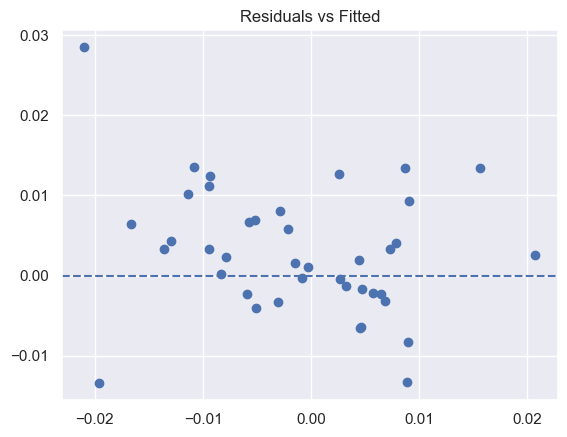

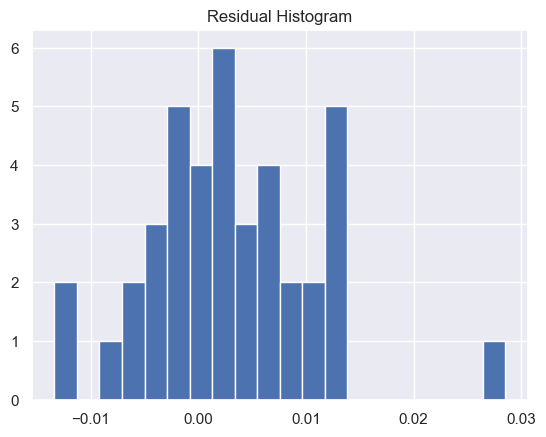

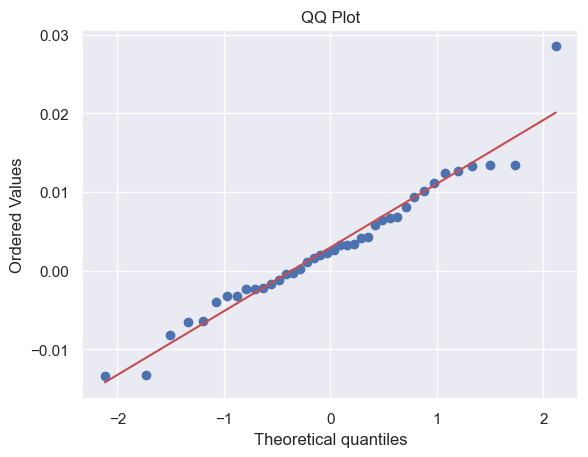

In [4]:
resid = y_test - y_pred
fitted = y_pred
plt.figure(); plt.scatter(fitted, resid); plt.axhline(0, ls='--'); plt.title('Residuals vs Fitted'); plt.show()
plt.figure(); plt.hist(resid, bins=20); plt.title('Residual Histogram'); plt.show()
plt.figure(); st.probplot(resid, dist='norm', plot=plt); plt.title('QQ Plot'); plt.show()

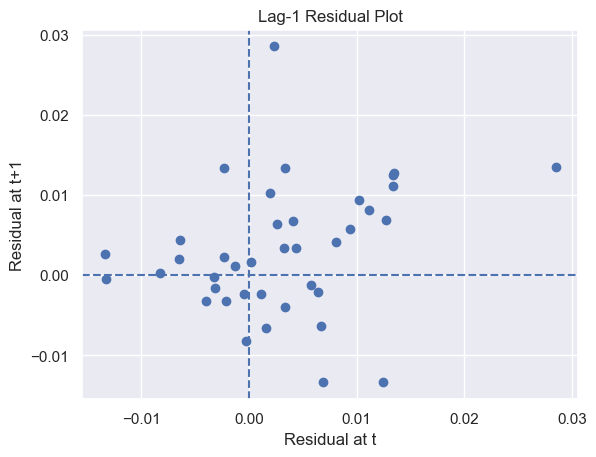

Lag-1 residual correlation: 0.2600


In [5]:
plt.figure()
plt.scatter(resid[:-1], resid[1:])
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')
plt.xlabel('Residual at t')
plt.ylabel('Residual at t+1')
plt.title('Lag-1 Residual Plot')
plt.show()

lag1_corr = np.corrcoef(resid[:-1], resid[1:])[0, 1]
print(f'Lag-1 residual correlation: {lag1_corr:.4f}')

## 3) Optional: Add a transformed feature
Add a polynomial or interaction if diagnostics suggest mis-specification.

In [6]:
df['momentum_sq'] = df['momentum']**2
X2 = df[['mkt_excess','size','value','momentum','momentum_sq']]
X2_train, X2_test = X2.iloc[:len(X_train)], X2.iloc[len(X_train):]
lr2 = LinearRegression().fit(X2_train, y_train)
y_pred2 = lr2.predict(X2_test)
r2_2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))
print(f'With x^2   R²={r2_2:.4f}  RMSE={rmse_2:.6f}')

With x^2   R²=0.3681  RMSE=0.008467


## 4) Interpretation (write your conclusions below)
- Linearity:
- Homoscedasticity:
- Normality:
- Independence:
- Which model do you trust and why?:
- Next step you’d try:

- **Independence:** The lag-1 residual correlation is about `0.26`, which suggests some positive dependence between consecutive residuals. The independence assumption may therefore be only partially satisfied. Because the data are time-ordered, a time-series model or lagged terms could be considered in Stage 10b.
## Interpretation

- **Linearity:** The residuals vs fitted plot does not show a strong systematic curve, so the linearity assumption appears reasonably satisfied. However, there are a few larger residuals, so the fit is not perfect.

- **Homoscedasticity:** The residual spread is not perfectly constant across fitted values. Some observations show noticeably larger residuals, suggesting possible mild heteroscedasticity. Therefore, the constant-variance assumption may only be approximately satisfied.

- **Normality:** The residual histogram is roughly centered near zero, and most points in the QQ plot lie close to the reference line. However, the tails deviate from the line, especially on the upper end, so the residuals are only approximately normal.

- **Independence:** The lag-1 residual correlation is about `0.26`, which suggests some positive dependence between consecutive residuals. The independence assumption may therefore be only partially satisfied. Because the data are time-ordered, a time-series model or lagged terms could be considered in Stage 10b.

- **Which model do I trust and why?** The transformed model with `momentum_sq` has only a very small improvement over the baseline model. R² increased from about `0.3677` to `0.3681`, while RMSE decreased from about `0.008470` to `0.008467`. Because the improvement is negligible, I would prefer the simpler baseline model unless there is a strong theoretical reason to include the squared momentum term.

- **Explanation vs prediction:** For explanation, I would be cautious because the residual diagnostics suggest mild violations of independence, homoscedasticity, and tail normality. For prediction, the model may still be useful as a baseline, but its R² indicates that a large share of variation in `asset_excess` remains unexplained.

- **Next step I would try:** I would investigate time dependence more directly in Stage 10b, for example by adding lagged terms or using a time-series model. I would also consider methods that are more robust to changing residual variance if heteroscedasticity remains a concern.